In [226]:
import tensorflow as tf
import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import math
import random

In [227]:
dataset = load_dataset("glue", "stsb")
train_data = dataset["train"]
validation_data = dataset["validation"]
test_data = dataset["test"]

In [228]:
def clean(text):
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [229]:
def preprocess(example):

    return {
        "sentence1": clean(example["sentence1"]),
        "sentence2": clean(example["sentence2"]),
        "label": example["label"] / 5.0
    }

In [230]:
train_data = train_data.map(preprocess)
validation_data = validation_data.map(preprocess)
test_data = test_data.map(preprocess)

In [231]:
print(train_data[0])

{'sentence1': 'a plane is taking off.', 'sentence2': 'an air plane is taking off.', 'label': 1.0, 'idx': 0}


In [232]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [233]:
def tokenize(example):

    s1 = tokenizer(
        example["sentence1"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

    s2 = tokenizer(
        example["sentence2"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

    return {
        "input_ids_1": s1["input_ids"],
        "attention_mask_1": s1["attention_mask"],

        "input_ids_2": s2["input_ids"],
        "attention_mask_2": s2["attention_mask"],

        "label": example["label"]
    }

In [234]:
train_data = train_data.map(tokenize)
validation_data = validation_data.map(tokenize)
test_data = test_data.map(tokenize)

In [235]:
print(train_data[9])

{'sentence1': 'a person is throwing a cat on to the ceiling.', 'sentence2': 'a person throws a cat on the ceiling.', 'label': 1.0, 'idx': 9, 'input_ids_1': [101, 1037, 2711, 2003, 6886, 1037, 4937, 2006, 2000, 1996, 5894, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask_1': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'input_ids_2': 

--- Descriptive Statistics for Similarity Labels ---
count    5749.00000
mean        0.54020
std         0.29288
min         0.00000
25%         0.30000
50%         0.60000
75%         0.76000
max         1.00000
Name: label, dtype: float64

--- Descriptive Statistics for Sentence 1 Token Lengths ---
count    5749.000000
mean       14.389459
std         7.376223
min         6.000000
25%        10.000000
50%        12.000000
75%        16.000000
max        70.000000
Name: length_s1, dtype: float64

--- Descriptive Statistics for Sentence 2 Token Lengths ---
count    5749.000000
mean       14.420421
std         7.311620
min         5.000000
25%        10.000000
50%        12.000000
75%        16.000000
max        63.000000
Name: length_s2, dtype: float64


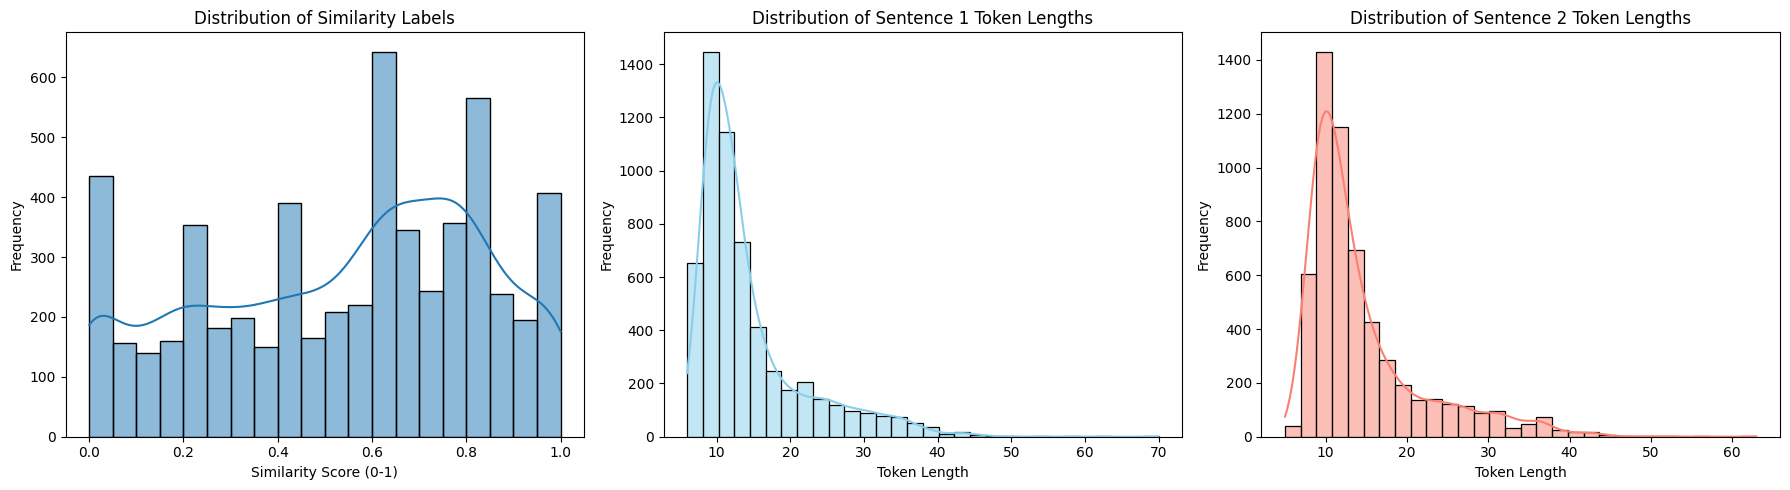

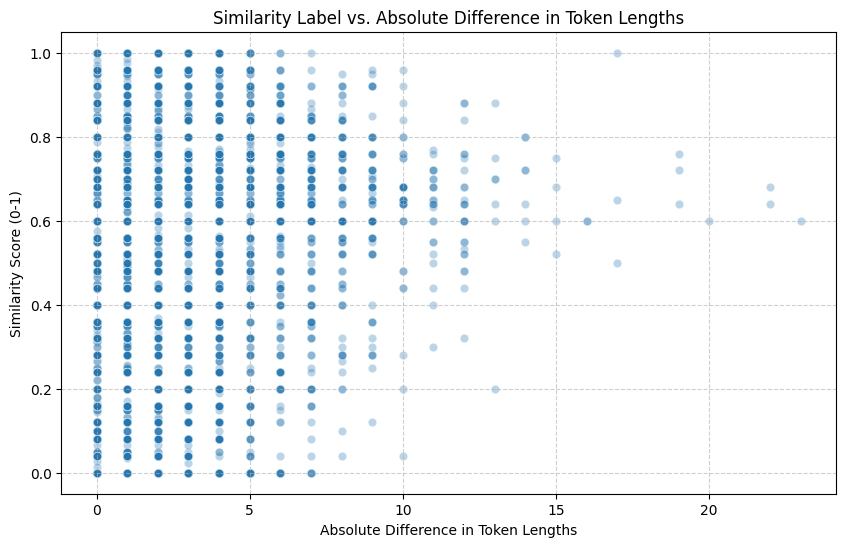

<Figure size 1000x800 with 0 Axes>

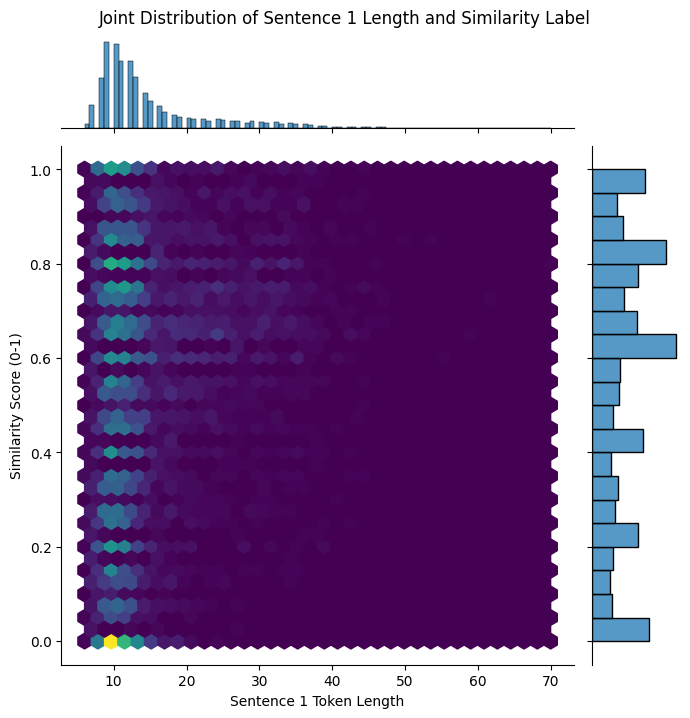

In [236]:
labels = [example["label"] for example in train_data]
len_s1 = [sum(example["attention_mask_1"]) for example in train_data]
len_s2 = [sum(example["attention_mask_2"]) for example in train_data]

df_analysis = pd.DataFrame({
    'label': labels,
    'length_s1': len_s1,
    'length_s2': len_s2
})

print("--- Descriptive Statistics for Similarity Labels ---")
print(df_analysis['label'].describe())
print("\n--- Descriptive Statistics for Sentence 1 Token Lengths ---")
print(df_analysis['length_s1'].describe())
print("\n--- Descriptive Statistics for Sentence 2 Token Lengths ---")
print(df_analysis['length_s2'].describe())

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df_analysis['label'], bins=20, kde=True)
plt.title('Distribution of Similarity Labels')
plt.xlabel('Similarity Score (0-1)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(df_analysis['length_s1'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Sentence 1 Token Lengths')
plt.xlabel('Token Length')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.histplot(df_analysis['length_s2'], bins=30, kde=True, color='salmon')
plt.title('Distribution of Sentence 2 Token Lengths')
plt.xlabel('Token Length')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

df_analysis['length_diff'] = abs(df_analysis['length_s1'] - df_analysis['length_s2'])

plt.figure(figsize=(10, 6))
sns.scatterplot(x='length_diff', y='label', data=df_analysis, alpha=0.3)
plt.title('Similarity Label vs. Absolute Difference in Token Lengths')
plt.xlabel('Absolute Difference in Token Lengths')
plt.ylabel('Similarity Score (0-1)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(10, 8))
sns.jointplot(x='length_s1', y='label', data=df_analysis, kind='hex', height=7, cmap='viridis')
plt.suptitle('Joint Distribution of Sentence 1 Length and Similarity Label', y=1.02)
plt.xlabel('Sentence 1 Token Length')
plt.ylabel('Similarity Score (0-1)')
plt.show()

In [237]:
train_tf = train_data.to_tf_dataset(
    columns=[
        "input_ids_1",
        "attention_mask_1",
        "input_ids_2",
        "attention_mask_2"
    ],
    label_cols="label",
    batch_size=32,
    shuffle=True
)

val_tf = validation_data.to_tf_dataset(
    columns=[
        "input_ids_1",
        "attention_mask_1",
        "input_ids_2",
        "attention_mask_2"
    ],
    label_cols="label",
    batch_size=32
)

print("--- Debug: Inspecting first 5 test_data entries before conversion to tf.data.Dataset ---")
for i in range(min(5, len(test_data))):
    entry = test_data[i]
    print(f"Entry {i}: sentence1='{entry['sentence1']}', sentence2='{entry['sentence2']}', label={entry['label']}, idx={entry['idx']}")
print("--- End Debug ---")

test_tf = test_data.to_tf_dataset(
    columns=[
        "input_ids_1",
        "attention_mask_1",
        "input_ids_2",
        "attention_mask_2"
    ],
    label_cols="label",
    batch_size=32
)

--- Debug: Inspecting first 5 test_data entries before conversion to tf.data.Dataset ---
Entry 0: sentence1='a girl is styling her hair.', sentence2='a girl is brushing her hair.', label=-0.20000000298023224, idx=0
Entry 1: sentence1='a group of men play soccer on the beach.', sentence2='a group of boys are playing soccer on the beach.', label=-0.20000000298023224, idx=1
Entry 2: sentence1='one woman is measuring another woman's ankle.', sentence2='a woman measures another woman's ankle.', label=-0.20000000298023224, idx=2
Entry 3: sentence1='a man is cutting up a cucumber.', sentence2='a man is slicing a cucumber.', label=-0.20000000298023224, idx=3
Entry 4: sentence1='a man is playing a harp.', sentence2='a man is playing a keyboard.', label=-0.20000000298023224, idx=4
--- End Debug ---


In [238]:
vocab_size = tokenizer.vocab_size
max_len = 128
d_model = 256
num_heads = 4
num_layers = 10
dropout = 0.1

In [239]:
print(vocab_size)

30522


In [240]:
class PositionalEmbedding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.pos_emb = layers.Embedding(max_len, d_model)

    def call(self, x):
        positions = tf.range(tf.shape(x)[1])
        return self.pos_emb(positions)

In [241]:
class TransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, dropout, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.num_heads = num_heads
        self.dropout = dropout

    def build(self, input_shape):
        self.att = layers.MultiHeadAttention(
            num_heads=self.num_heads,
            key_dim=self.d_model // self.num_heads
        )

        self.ffn = keras.Sequential([
            layers.Dense(4 * self.d_model, activation="gelu"),
            layers.Dense(self.d_model)
        ])

        self.ln1 = layers.LayerNormalization()
        self.ln2 = layers.LayerNormalization()
        self.drop = layers.Dropout(self.dropout)

    def call(self, x):
        a = self.att(x, x)
        x = self.ln1(x + self.drop(a))

        f = self.ffn(x)
        x = self.ln2(x + self.drop(f))
        return x

    def get_config(self):
        return {
            "d_model": self.d_model,
            "num_heads": self.num_heads,
            "dropout": self.dropout
        }

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [242]:
class Encoder(keras.Model):
    def __init__(self, vocab_size, max_len, d_model, num_heads, num_layers, dropout, **kwargs):
        super().__init__(**kwargs)

        self.vocab_size = vocab_size
        self.max_len = max_len
        self.d_model = d_model
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.dropout = dropout

        self.token_emb = layers.Embedding(vocab_size, d_model)
        self.pos_emb = PositionalEmbedding(max_len, d_model)

        self.blocks = [
            TransformerBlock(d_model, num_heads, dropout)
            for _ in range(num_layers)
        ]

        self.pool = layers.GlobalAveragePooling1D()
        self.proj = layers.Dense(d_model)

    def call(self, x):
        x = self.token_emb(x)
        x = x + self.pos_emb(x)

        for b in self.blocks:
            x = b(x)

        x = self.pool(x)
        x = self.proj(x)

        return tf.nn.l2_normalize(x, axis=-1)
    def get_config(self):
        config = super().get_config()
        config.update({
            "vocab_size": self.vocab_size,
            "max_len": self.max_len,
            "d_model": self.d_model,
            "num_heads": self.num_heads,
            "num_layers": self.num_layers,
            "dropout": self.dropout,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [243]:
def cosine_sim(a, b):
    return tf.reduce_sum(a * b, axis=-1)

In [244]:
class SiameseModel(keras.Model):

    def __init__(self, encoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder

    def call(self, inputs):
        s1 = inputs["input_ids_1"]
        s2 = inputs["input_ids_2"]

        e1 = self.encoder(s1)
        e2 = self.encoder(s2)

        sim = tf.reduce_sum(e1 * e2, axis=-1, keepdims=True)
        return sim

    def get_config(self):
        config = super().get_config()
        config.update({
            "encoder": keras.utils.serialize_keras_object(self.encoder)
        })
        return config

    @classmethod
    def from_config(cls, config):
        encoder_cfg = config.pop("encoder")

        encoder = keras.utils.deserialize_keras_object(
            encoder_cfg,
            custom_objects={
                "Encoder": Encoder,
                "TransformerBlock": TransformerBlock,
                "PositionalEmbedding": PositionalEmbedding
            }
        )

        return cls(encoder=encoder, **config)

In [245]:
def contrastive_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)

    margin = 0.5

    pos_loss = y_true * tf.square(1 - y_pred)
    neg_loss = (1 - y_true) * tf.square(tf.maximum(y_pred - margin, 0))

    return tf.reduce_mean(pos_loss + neg_loss)

In [246]:
vocab_size = tokenizer.vocab_size
max_len = 128
d_model = 256
num_heads = 4
num_layers = 6
dropout = 0.1

encoder = Encoder(vocab_size, max_len, d_model, num_heads, num_layers, dropout)
model = SiameseModel(encoder)

In [247]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=contrastive_loss
)

In [248]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
history = model.fit(
    train_tf,
    validation_data=val_tf,
    epochs=20,
    callbacks=[callback]
)

Epoch 1/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 83s 282ms/step - loss: 0.1056 - val_loss: 0.1019
Epoch 2/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 25s 136ms/step - loss: 0.0739 - val_loss: 0.0746
Epoch 3/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 26s 146ms/step - loss: 0.0574 - val_loss: 0.0674
Epoch 4/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 25s 137ms/step - loss: 0.0488 - val_loss: 0.0652
Epoch 5/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 25s 136ms/step - loss: 0.0452 - val_loss: 0.0620
Epoch 6/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 25s 139ms/step - loss: 0.0435 - val_loss: 0.0621
Epoch 7/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 25s 139ms/step - loss: 0.0428 - val_loss: 0.0619
Epoch 8/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 25s 136ms/step - loss: 0.0425 - val_loss: 0.0618
Epoch 9/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 25s 137ms/step - loss: 0.0424 - val_loss: 0.0625
Epoch 10/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 25s 139ms/step - loss: 0.0424 - val_loss: 0.0626
Epoch 11/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 25s 138ms/step - loss: 0.0423 - val_loss: 0.0623


In [249]:
model.evaluate(test_tf)

44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.1068


0.10678766667842865

In [250]:
def predict(s1, s2):

    s1 = tokenizer(
        s1,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="np"
    )

    s2 = tokenizer(
        s2,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="np"
    )

    inputs = {
        "input_ids_1": tf.constant(s1["input_ids"]),
        "input_ids_2": tf.constant(s2["input_ids"])
    }

    return float(model(inputs)[0][0])

In [251]:
predict(
    "He bought a new phone yesterday",
    "Yesterday he purchased a smartphone"
)

0.6978476643562317

In [252]:
dummy = {
    "input_ids_1": tf.zeros((1,128), dtype=tf.int32),
    "input_ids_2": tf.zeros((1,128), dtype=tf.int32)
}

model(dummy)

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[1.0000002]], dtype=float32)>

In [253]:
model.save("semantic_bert.keras")

In [254]:
tokenizer.save_pretrained("bert_tokenizer")
print("Tokenizer saved to 'bert_tokenizer' directory.")

Tokenizer saved to 'bert_tokenizer' directory.


In [255]:
model = keras.models.load_model(
    "semantic_bert.keras",
    custom_objects={
        "Encoder": Encoder,
        "TransformerBlock": TransformerBlock,
        "PositionalEmbedding": PositionalEmbedding
    }
)

Loading the saved tokenizer...
Tokenizer loaded successfully.
Loading the saved model...


TypeError: Could not locate function 'contrastive_loss'. Make sure custom classes and functions are decorated with `@keras.saving.register_keras_serializable()`. If they are already decorated, make sure they are all imported so that the decorator is run before trying to load them. Full object config: {'module': 'builtins', 'class_name': 'function', 'config': 'contrastive_loss', 'registered_name': 'function'}

In [256]:
def predict(sentence1, sentence2):

    s1 = tokenizer(
        sentence1,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="np"
    )

    s2 = tokenizer(
        sentence2,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="np"
    )

    inputs = {
        "input_ids_1": tf.constant(s1["input_ids"]),
        "input_ids_2": tf.constant(s2["input_ids"])
    }

    sim = model(inputs)

    return float(sim[0][0])

In [257]:
print(predict(
    "A man is playing guitar",
    "A person is playing guitar"
))

print(predict(
    "The sky is blue",
    "A dog is running in the park"
))

print(predict(
    "He bought a phone yesterday",
    "Yesterday he purchased a smartphone"
))

0.8699761033058167
0.737795889377594
0.7731379270553589


In [261]:
print(predict(
    "How are you",
    "How are you"
))

print(predict(
    "The sky is blue",
    "The sky is blue"
))

print(predict(
    "He bought a phone yesterday",
    "Yesterday he purchased a smartphone"
))

1.0000001192092896
1.0
0.7731379270553589
